# 🎨 Learning Visualization with SkillCorner Open Data

This notebook demonstrates how to **use and apply the SkillCorner visualization library** with data from the A-League 24/25 season.

You can find an online version of this notebook here: https://colab.research.google.com/drive/1frYsXKaH8jhJOTwHPFDi78Dmjunwd2Jh


## 📋 Step 1: Setup & Prerequisites


In [19]:
# Install libraries
# !pip install skillcornerviz
# !pip install skillcorner

# Import visualizations
from skillcornerviz.standard_plots import bar_plot as bar
from skillcornerviz.standard_plots import radar_plot as rad
from skillcornerviz.standard_plots import scatter_plot as scatter
from skillcornerviz.standard_plots import swarm_violin_plot as svp


## 📥 Step 2: Load Physical Data


In [20]:
# Option 1: Fork opendata github repo and work in your local environment
# Link to repo: https://github.com/SkillCorner/opendata


In [21]:
# Option 2: Load Physical CSV file directly from Github Open Data below

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

url = "../../../data/aggregates/aus1league_physicalaggregates_20242025.csv"

physical_df = pd.read_csv(url)
print(f"physical_df shape - {physical_df.shape}")
physical_df.head()


physical_df shape - (406, 65)


,player_name,player_short_name,player_id,player_birthdate,team_name,team_id,competition_name,competition_id,season_name,season_id,position_group,minutes_full_all,minutes_full_tip,minutes_full_otip,count_match,count_match_failed,total_distance_full_all,total_metersperminute_full_all,running_distance_full_all,hsr_distance_full_all,hsr_count_full_all,sprint_distance_full_all,sprint_count_full_all,hi_distance_full_all,hi_count_full_all,medaccel_count_full_all,highaccel_count_full_all,meddecel_count_full_all,highdecel_count_full_all,explacceltohsr_count_full_all,timetohsr_top3,explacceltosprint_count_full_all,timetosprint_top3,psv99,psv99_top5,total_distance_full_tip,total_metersperminute_full_tip,running_distance_full_tip,hsr_distance_full_tip,hsr_count_full_tip,sprint_distance_full_tip,sprint_count_full_tip,hi_distance_full_tip,hi_count_full_tip,medaccel_count_full_tip,highaccel_count_full_tip,meddecel_count_full_tip,highdecel_count_full_tip,explacceltohsr_count_full_tip,explacceltosprint_count_full_tip,total_distance_full_otip,total_metersperminute_full_otip,running_distance_full_otip,hsr_distance_full_otip,hsr_count_full_otip,sprint_distance_full_otip,sprint_count_full_otip,hi_distance_full_otip,hi_count_full_otip,medaccel_count_full_otip,highaccel_count_full_otip,meddecel_count_full_otip,highdecel_count_full_otip,explacceltohsr_count_full_otip,explacceltosprint_count_full_otip
0,Adam Taggart,A. Taggart,211,1993-06-02,Perth Glory Football Club,871,AUS - A-League,61,2024/2025,95,Center Forward,96.78,22.29,32.04,24,0,10515.04,108.64,1413.42,572.67,59.54,184.08,11.00,756.75,70.54,119.38,10.46,99.46,21.67,7.38,0.63,1.25,1.35,28.83,29.98,3087.92,138.53,533.83,288.08,29.71,120.83,6.50,408.92,36.21,43.08,3.42,26.29,5.67,2.50,0.67,4423.04,138.05,755.33,249.38,24.21,48.46,3.00,297.83,27.21,42.38,2.67,38.25,6.96,1.92,0.08
1,Adama Traoré,A. Traoré,218,1990-02-03,Melbourne Victory Football Club,868,AUS - A-League,61,2024/2025,95,Full Back,89.05,26.23,19.99,6,0,9173.67,103.02,1088.83,430.67,43.67,141.33,8.67,572.00,52.33,102.17,5.33,84.17,16.17,3.50,0.72,1.00,1.70,30.07,30.24,3411.67,130.05,478.17,157.00,16.17,60.67,2.83,217.67,19.00,35.50,1.83,26.00,4.00,1.00,0.17,2789.33,139.51,480.17,245.67,21.00,69.67,4.00,315.33,25.00,37.83,2.00,25.67,4.50,1.17,0.50
2,Dino Arslanagić,D. Arslanagić,2759,1993-04-24,Macarthur FC,1804,AUS - A-League,61,2024/2025,95,Central Defender,96.46,28.33,26.86,8,0,9563.50,99.14,1041.12,281.25,23.38,38.25,2.50,319.50,25.88,107.25,3.88,86.12,9.62,3.00,0.80,0.38,NaN,25.82,26.48,3248.62,114.68,320.50,57.38,4.62,6.38,0.12,63.75,4.75,28.62,1.00,24.00,1.88,0.38,0.12,3517.12,130.95,559.00,194.12,15.62,29.12,1.25,223.25,16.88,45.12,1.75,30.75,3.50,1.25,0.00
3,Douglas Costa de Souza,Douglas Costa,2858,1990-09-14,Sydney Football Club,869,AUS - A-League,61,2024/2025,95,Center Forward,94.25,27.43,24.81,4,0,10521.25,111.64,1425.50,406.75,36.00,71.25,4.25,478.00,40.25,91.50,6.50,74.00,10.50,3.25,0.78,0.50,NaN,26.38,26.38,3782.50,137.92,632.75,186.50,16.75,39.25,1.75,225.75,18.50,41.00,2.75,26.50,3.75,1.50,0.00,3652.50,147.23,662.00,199.25,15.50,28.00,2.00,227.25,17.50,28.75,2.00,25.00,3.00,0.75,0.25
4,Douglas Costa de Souza,Douglas Costa,2858,1990-09-14,Sydney Football Club,869,AUS - A-League,61,2024/2025,95,Midfield,67.57,20.63,17.78,1,0,7843.00,116.08,1307.00,318.00,26.00,10.00,2.00,328.00,28.00,67.00,3.00,58.00,7.00,2.00,NaN,0.00,NaN,24.60,24.60,2822.00,136.77,556.00,121.00,9.00,9.00,1.00,130.00,10.00,22.00,1.00,17.00,3.00,1.00,0.00,2840.00,159.70,637.00,169.00,16.00,1.00,0.00,170.00,16.00,26.00,0.00,21.00,2.00,0.00,0.00


Lines on "aggregate data" from the README file

```text
📊 Season Aggregates (Physical, OBR, Passing)
The aggregate data is provided at a player-season level and contains key metrics across three categories:
- Physical: Metrics such as PSV99, high-intensity counts, and distance covered.
- Off-Ball Runs (OBR): Tactical metrics identifying types of runs and their outcomes.
- Passing: Aggregated passing volume and efficiency metrics.
The datasets are filtered for performances above 60 minutes only.
```


In [22]:
# Explore unique columns
print(len(physical_df.columns))
print(len(physical_df.columns.unique()))
physical_df.columns.unique()


65
65


Index(['player_name', 'player_short_name', 'player_id', 'player_birthdate',
       'team_name', 'team_id', 'competition_name', 'competition_id',
       'season_name', 'season_id', 'position_group', 'minutes_full_all',
       'minutes_full_tip', 'minutes_full_otip', 'count_match',
       'count_match_failed', 'total_distance_full_all',
       'total_metersperminute_full_all', 'running_distance_full_all',
       'hsr_distance_full_all', 'hsr_count_full_all',
       'sprint_distance_full_all', 'sprint_count_full_all',
       'hi_distance_full_all', 'hi_count_full_all', 'medaccel_count_full_all',
       'highaccel_count_full_all', 'meddecel_count_full_all',
       'highdecel_count_full_all', 'explacceltohsr_count_full_all',
       'timetohsr_top3', 'explacceltosprint_count_full_all',
       'timetosprint_top3', 'psv99', 'psv99_top5', 'total_distance_full_tip',
       'total_metersperminute_full_tip', 'running_distance_full_tip',
       'hsr_distance_full_tip', 'hsr_count_full_tip',
       

In [23]:
print(
    f"The # seasons in dataframe - {len(physical_df.season_id.unique())} ({physical_df.season_name.unique()[0]})",
)
print(
    f"The # competitions in dataframe - {len(physical_df.competition_id.unique())} ({physical_df.competition_name.unique()[0]})",
)
print(f"The # players in dataframe - {len(physical_df.player_id.unique())}")
print(f"The # teams in dataframe - {len(physical_df.team_id.unique())}")
print(f"The # rows in dataframe - {physical_df.shape[0]}")


The # seasons in dataframe - 1 (2024/2025)
The # competitions in dataframe - 1 (AUS - A-League)
The # players in dataframe - 268
The # teams in dataframe - 13
The # rows in dataframe - 406


In [24]:
physical_df.duplicated().sum()


np.int64(0)

In [25]:
physical_df.duplicated(["player_id"]).sum()


np.int64(138)

In [26]:
138 + 268


406

In [27]:
physical_df.duplicated(["player_id", "team_id"]).sum()


np.int64(135)

In [28]:
physical_df.duplicated(["player_id", "team_id", "position_group"]).sum()


np.int64(0)

> Question: How many of the 268 player_ids occur only once? That means that player played for the same team and in the same position throughout the course of the season.


In [29]:
players_grouped = physical_df[["player_id", "team_id", "position_group"]].groupby(
    "player_id"
)
print((players_grouped.size() > 1).sum())
print((players_grouped.size() == 2).sum())
print((players_grouped.size() == 3).sum())
print((players_grouped.size() == 4).sum())


104
77
20
7


In [30]:
77 + 20 + 7


104

iska matlab aisa hai

- 268 me se, 104 players aise hai jo double, triple ya four times aa rahe hain.
- 268-104 = **164** players aise hai jo same team AND same position_group me khele hain.


In [31]:
cols_to_drop = [
    "player_short_name",
    "season_name",
    "season_id",
    "competition_name",
    "competition_id",
    "team_name",
]

physical_df.drop(columns=cols_to_drop).head()


,player_name,player_id,player_birthdate,team_id,position_group,minutes_full_all,minutes_full_tip,minutes_full_otip,count_match,count_match_failed,total_distance_full_all,total_metersperminute_full_all,running_distance_full_all,hsr_distance_full_all,hsr_count_full_all,sprint_distance_full_all,sprint_count_full_all,hi_distance_full_all,hi_count_full_all,medaccel_count_full_all,highaccel_count_full_all,meddecel_count_full_all,highdecel_count_full_all,explacceltohsr_count_full_all,timetohsr_top3,explacceltosprint_count_full_all,timetosprint_top3,psv99,psv99_top5,total_distance_full_tip,total_metersperminute_full_tip,running_distance_full_tip,hsr_distance_full_tip,hsr_count_full_tip,sprint_distance_full_tip,sprint_count_full_tip,hi_distance_full_tip,hi_count_full_tip,medaccel_count_full_tip,highaccel_count_full_tip,meddecel_count_full_tip,highdecel_count_full_tip,explacceltohsr_count_full_tip,explacceltosprint_count_full_tip,total_distance_full_otip,total_metersperminute_full_otip,running_distance_full_otip,hsr_distance_full_otip,hsr_count_full_otip,sprint_distance_full_otip,sprint_count_full_otip,hi_distance_full_otip,hi_count_full_otip,medaccel_count_full_otip,highaccel_count_full_otip,meddecel_count_full_otip,highdecel_count_full_otip,explacceltohsr_count_full_otip,explacceltosprint_count_full_otip
0,Adam Taggart,211,1993-06-02,871,Center Forward,96.78,22.29,32.04,24,0,10515.04,108.64,1413.42,572.67,59.54,184.08,11.00,756.75,70.54,119.38,10.46,99.46,21.67,7.38,0.63,1.25,1.35,28.83,29.98,3087.92,138.53,533.83,288.08,29.71,120.83,6.50,408.92,36.21,43.08,3.42,26.29,5.67,2.50,0.67,4423.04,138.05,755.33,249.38,24.21,48.46,3.00,297.83,27.21,42.38,2.67,38.25,6.96,1.92,0.08
1,Adama Traoré,218,1990-02-03,868,Full Back,89.05,26.23,19.99,6,0,9173.67,103.02,1088.83,430.67,43.67,141.33,8.67,572.00,52.33,102.17,5.33,84.17,16.17,3.50,0.72,1.00,1.70,30.07,30.24,3411.67,130.05,478.17,157.00,16.17,60.67,2.83,217.67,19.00,35.50,1.83,26.00,4.00,1.00,0.17,2789.33,139.51,480.17,245.67,21.00,69.67,4.00,315.33,25.00,37.83,2.00,25.67,4.50,1.17,0.50
2,Dino Arslanagić,2759,1993-04-24,1804,Central Defender,96.46,28.33,26.86,8,0,9563.50,99.14,1041.12,281.25,23.38,38.25,2.50,319.50,25.88,107.25,3.88,86.12,9.62,3.00,0.80,0.38,NaN,25.82,26.48,3248.62,114.68,320.50,57.38,4.62,6.38,0.12,63.75,4.75,28.62,1.00,24.00,1.88,0.38,0.12,3517.12,130.95,559.00,194.12,15.62,29.12,1.25,223.25,16.88,45.12,1.75,30.75,3.50,1.25,0.00
3,Douglas Costa de Souza,2858,1990-09-14,869,Center Forward,94.25,27.43,24.81,4,0,10521.25,111.64,1425.50,406.75,36.00,71.25,4.25,478.00,40.25,91.50,6.50,74.00,10.50,3.25,0.78,0.50,NaN,26.38,26.38,3782.50,137.92,632.75,186.50,16.75,39.25,1.75,225.75,18.50,41.00,2.75,26.50,3.75,1.50,0.00,3652.50,147.23,662.00,199.25,15.50,28.00,2.00,227.25,17.50,28.75,2.00,25.00,3.00,0.75,0.25
4,Douglas Costa de Souza,2858,1990-09-14,869,Midfield,67.57,20.63,17.78,1,0,7843.00,116.08,1307.00,318.00,26.00,10.00,2.00,328.00,28.00,67.00,3.00,58.00,7.00,2.00,NaN,0.00,NaN,24.60,24.60,2822.00,136.77,556.00,121.00,9.00,9.00,1.00,130.00,10.00,22.00,1.00,17.00,3.00,1.00,0.00,2840.00,159.70,637.00,169.00,16.00,1.00,0.00,170.00,16.00,26.00,0.00,21.00,2.00,0.00,0.00


Physical metrics

1. **Total Distance**: Total distance covered.
1. **M/min**: Total distance covered divided per number of minutes. For TIP (resp OTIP), it's divided per number of minutes TIP (resp OTIP).
1. **Running Distance**: Distance covered between 15km/h and 20km/h.
1. **High Speed Running (HSR) Distance**: Distance covered between 20 and 25 km/h.
1. **Sprinting Distance**: Distance covered above 25 km/h.
1. **High Intensity (HI) Distance**: Distance covered above 20 km/h.
1. **Count HSR**: Discrete activity with a speed moving average over one-second window between 20 and 25 km/h.
1. **Count Sprint**: Discrete activity with a speed moving average over one-second window higher than 25 km/h.
1. **Count HI**: Sum of Count HSR and Count Sprint.
1. **Count Medium Acceleration**: Discrete activity between 1.5 m/s² and 3 m/s². The activity needs to last for at least 0.7s.
1. **Count High Acceleration**: Discrete activity exceeding 3 m/s². The activity needs to last for at least 0.7s.
1. **Count Medium Deceleration**: Discrete activity between -1.5 m/s² and -3 m/s². The activity needs to last for at least 0.7s.
1. **Count High Deceleration**: Discrete activity under -3 m/s². The activity needs to last for at least 0.7s.
1. **PSV-99**: Peak sprint velocity 99th percentile. This metric reflects the peak speed of a player and its ability to reach it multiple times or sustain it long enough.
1. **TOP 5 PSV-99**: When averaged by player only. Best 5 PSV-99 performances by player.
1. **Count Explosive Acceleration to HSR**: Count of High Accelerations (see definition above) starting from a speed below 9km/h and reaching at least 20 km/h.
1. **Count Explosive Acceleration to Sprint**: Count of High Accelerations (see definition above) starting from a speed below 9km/h and reaching at least 25 km/h.
1. **Time to HSR**: The minimum time spent between 9 km/h and 20 km/h when achieving an Explosive Acceleration to HSR during a performance.
1. **Time to HSR Post-COD**: the minimum time spent between 9 km/h and 20 km/h (5.5 m/s) when achieving an Explosive Acceleration to HSR after a change of direction during a performance.
1. **TOP 3 Time to HSR**: When averaging performances, provides the average of the 3 best Time to HSR performances. Note that this metric is provided only if the player has 3 performances with a Time to HSR.
1. **TOP 3 Time to HSR post-COD**: When averaging performances, provides the average of the 3 best Time to HSR post-COD performances. Note that this metric is provided only if the player has 3 performances with a Time to HSR post-COD.
1. **Time to Sprint**: The minimum time spent between 9 km/h and 25 km/h when achieving an Explosive Acceleration to Sprint during a performance.
1. **Time to Sprint Post-COD**: the minimum time spent between 9 km/h and 25 km/h (6.9 m/s) when achieving an Explosive Acceleration to Sprint after a change of direction during a performance.
1. **TOP 3 Time to Sprint**: When averaging performances, provides the average of the 3 best Time to Sprint performances. Note that this metric is provided only if the player has 3 performances with a Time to Sprint.
1. **TOP 3 Time to Sprint post-COD**: When averaging performances, provides the average of the 3 best Time to Sprint post-COD performances. Note that this metric is provided only if the player has 3 performances with a Time to Sprint post-COD.
1. **Change of Direction Count**: how many times a player performs an intense change of direction, regardless of the type of movement. Provides validation about the physical volume the player can sustain and the overall mobility.
1. **Time to 505 around 180**: the time a running player takes to cover the final 5 meters before a tight turn around 180° [150°-210°] plus the 5 first meters after it.
1. ‍‍**Time to 505 around 90**: the time a running player takes to cover the final 5 meters before a tight turn around 90° [70°-120°] plus the 5 first meters after it.
1. **TOP 3 Time to 505 around 180**: When averaging performances, provides the average of the 3 best Time to 505 around 180 performances. Note that this metric is provided only if the player has 3 performances with a Time to 505 around 180.
1. **TOP 3 Time to 505 around 90**: When averaging performances, provides the average of the 3 best Time to 505 around 90 performances. Note that this metric is provided only if the player has 3 performances with a Time to 505 around 90.

- out of these, 19, 21, 23, 25-30 are not in the `pysical_df`

> Split per period: All these physical metrics (except PSV-99) are split per period. We only have first half and second half split and no overtime.

> Split per possession type: All these physical metrics (except PSV-99) are split per possession type.

> TIP: When the team has the possession\
> OTIP: When the opponent team has the possession

Physical Quality check\
Performance: Appearance of a player in a match.

If a player played two matches it counts as two performances (two performances for the player).\
If two players played the same match it counts as two performances (one performance per player).\
If two players played two matches it counts as four performances (two performances per player).\
Quality Check (QC): Indicates if the quality of the data regarding a performance is high enough to be trustworthy. If it is then the quality check is passed and the data is provided, otherwise it is failed and no data is provided.


In [32]:
# Explore position groups
physical_df["position_group"].unique()


array(['Center Forward', 'Full Back', 'Central Defender', 'Midfield',
       'Wide Attacker'], dtype=object)

In [33]:
# Explore teams
physical_df["team_name"].unique()


array(['Perth Glory Football Club', 'Melbourne Victory Football Club',
       'Macarthur FC', 'Sydney Football Club', 'Auckland FC',
       'Adelaide United Football Club', 'Western Sydney Wanderers FC',
       'Wellington Phoenix FC', 'Melbourne City FC',
       'Central Coast Mariners Football Club', 'Western United',
       'Newcastle United Jets FC', 'Brisbane Roar FC'], dtype=object)

In [ ]:
null_values = physical_df.isna().sum()
null_values[null_values > 0]


player_birthdate       1
timetohsr_top3       147
timetosprint_top3    217
dtype: int64

In [ ]:
physical_df.shape


(406, 65)

## 📊 Step 3: Normalize Data


The raw data in this dataset consists of cumulative season totals. To compare players fairly regardless of how many matches they started or their total playing time, we must normalize these figures into Per 90 (P90) or Per 60 (P60) metrics. The P60 metric combines TIP (Team in Possession) and OTIP (Opponent Team In Possession) numbers to get "Ball In Play" Time.

**Per 90 Minutes**

Example:
(hi_count_full_all / minutes_full_all) \* 90

**Per 60 Minutes Ball in Play (BIP)**

Example:
(count_hi_full_tip+count_hi_full_otip)\*60/(minutes_full_tip+minutes_full_otip)

**Matches Played**

We use a minimum treshold of 5 games when comparing players physical data


In [ ]:
# Filter dataframe, physical_df for minimum 5 games
physical_df = physical_df[physical_df["count_match"] >= 5]
physical_df.shape


(210, 65)

In [ ]:
null_values = physical_df.isna().sum()
null_values[null_values > 0]


player_birthdate      1
timetosprint_top3    35
dtype: int64

In [40]:
# Normalizing metrics Per 90
physical_df["hi_count_p90"] = (
    physical_df["hi_count_full_all"] / physical_df["minutes_full_all"]
) * 90
physical_df["distance_p90"] = (
    physical_df["total_distance_full_all"] / physical_df["minutes_full_all"]
) * 90

# Normalizing metrics Per 60 BIP
physical_df["explosive_accels_to_sprint_p60"] = (
    (
        physical_df["explacceltosprint_count_full_tip"]
        + physical_df["explacceltosprint_count_full_otip"]
    )
    * 60
    / (physical_df["minutes_full_tip"] + physical_df["minutes_full_otip"])
)


In [41]:
# checking that new metrics have been included in physical_df
physical_df.columns.unique()


Index(['player_name', 'player_short_name', 'player_id', 'player_birthdate',
       'team_name', 'team_id', 'competition_name', 'competition_id',
       'season_name', 'season_id', 'position_group', 'minutes_full_all',
       'minutes_full_tip', 'minutes_full_otip', 'count_match',
       'count_match_failed', 'total_distance_full_all',
       'total_metersperminute_full_all', 'running_distance_full_all',
       'hsr_distance_full_all', 'hsr_count_full_all',
       'sprint_distance_full_all', 'sprint_count_full_all',
       'hi_distance_full_all', 'hi_count_full_all', 'medaccel_count_full_all',
       'highaccel_count_full_all', 'meddecel_count_full_all',
       'highdecel_count_full_all', 'explacceltohsr_count_full_all',
       'timetohsr_top3', 'explacceltosprint_count_full_all',
       'timetosprint_top3', 'psv99', 'psv99_top5', 'total_distance_full_tip',
       'total_metersperminute_full_tip', 'running_distance_full_tip',
       'hsr_distance_full_tip', 'hsr_count_full_tip',
       

## 🎨 Step 4: Visualize Data


### 4.1 Bar Chart

**PSV-99** stands for Peak Speed Velocity at the 99th percentile of the speed distribution, specifically considering speeds between 15 km/h and 40 km/h.

PSV-99 is not equivalent to the actual peak speed; it is typically lower than the real peak speed.

A high PSV-99 indicates an ability to repeat sprints at high velocity.


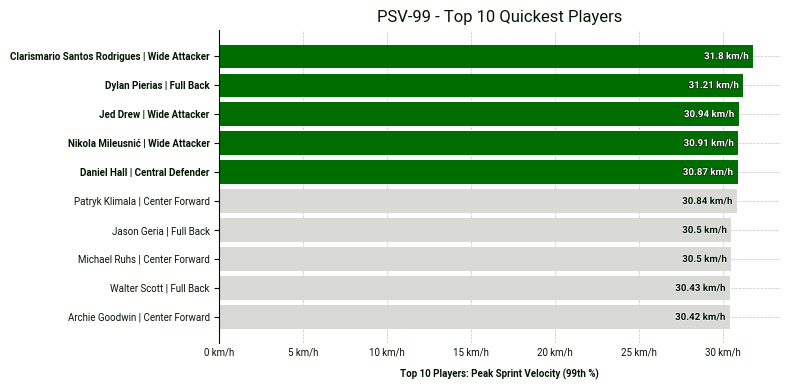

In [42]:
# 1. Sort by the metric and take the top 10
# Using 'psv_99' which is the column name
top_10_physical = physical_df.sort_values("psv99", ascending=False).head(10).copy()

# 2. Create the custom plot label (Name | Position)
# This combines the player name and their role for the Y-axis
top_10_physical["plot_label"] = (
    top_10_physical["player_name"] + " | " + top_10_physical["position_group"]
)

# 3. Automatically get the IDs of the top 5 to highlight them in green
top_5_ids = top_10_physical["player_id"].head(5).tolist()

# 4. Create the bar plot
fig, ax = bar.plot_bar_chart(
    df=top_10_physical,
    metric="psv99",
    label="Top 10 Players: Peak Sprint Velocity (99th %)",
    unit="km/h",
    primary_highlight_group=top_5_ids,  # These 5 will be green
    primary_highlight_color="#006D00",  # SkillCorner Green
    add_bar_values=True,
    data_point_id="player_id",  # Matches the IDs in top_5_ids
    data_point_label="plot_label",  # Uses the 'Name | Position' string
    plot_title="PSV-99 - Top 10 Quickest Players",
)


### 4.2 Swarm Plot

Here, we are looking at PSV-99 split by position groups on a team-level.


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
/home/sudarshan/projects/opendata/.venv/lib/python3.11/site-packages/skillcornerviz/standard_plots/swarm_violin_plot.py:249: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_group_labels,


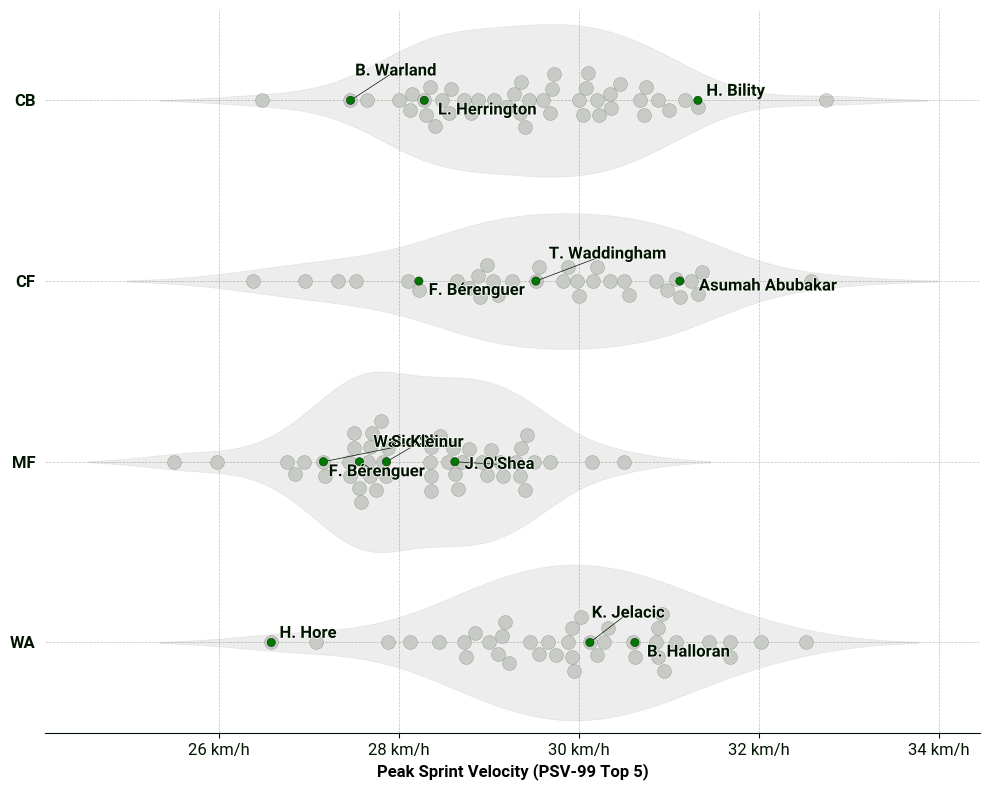

In [43]:
# 1. Define Labels and Units
x_label = "Peak Sprint Velocity (PSV-99 Top 5)"
x_unit = "km/h"
y_labels = ["CB", "CF", "MF", "WA"]

# 2. SIMPLE TEAM INPUT: Just change the team name here
target_team = "Brisbane Roar FC"
team_ids = physical_df[physical_df["team_name"] == target_team]["player_id"].tolist()

# 3. Create the Swarm-Violin Plot
fig, ax = svp.plot_swarm_violin(
    df=physical_df,
    x_metric="psv99_top5",
    y_metric="position_group",
    y_groups=["Central Defender", "Center Forward", "Midfield", "Wide Attacker"],
    x_label=x_label,
    y_group_labels=y_labels,
    x_unit=x_unit,
    data_point_id="player_id",
    data_point_label="player_short_name",
    # Highlights the entire team based on the name above
    # Adjust fig size and fonts as you wish
    secondary_highlight_group=team_ids,
    point_size=14,
    figsize=(10, 8),
    fontsize=12,
    label_fontsize=12,
)

plt.show()


### 4.3 Scatter Plot

Let's filter for attackers and plot their PSV-99 and frequency of High Intensity Activities Per 90 Minutes.


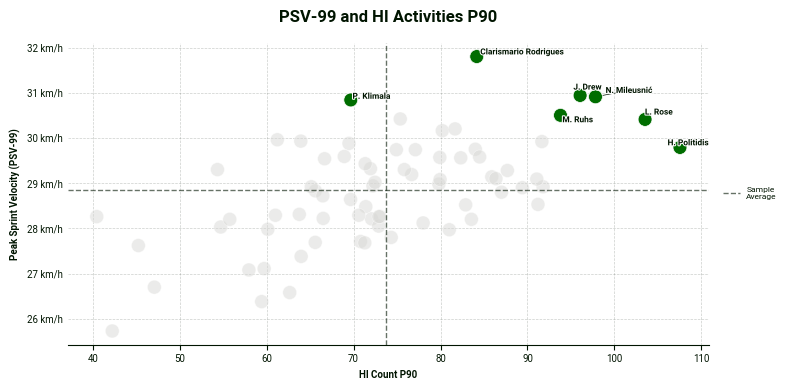

In [44]:
# Filter for Attackers
attackers_df = physical_df[
    physical_df["position_group"].isin(["Wide Attacker", "Center Forward"])
].copy()

# Identify the Top 5 in each category
top_5_speed_ids = (
    attackers_df.sort_values("psv99", ascending=False).head(5)["player_id"].tolist()
)
top_5_volume_ids = (
    attackers_df.sort_values("hi_count_p90", ascending=False)
    .head(5)["player_id"]
    .tolist()
)

# Combine both lists and remove duplicates
highlight_players = list(set(top_5_speed_ids + top_5_volume_ids))

# 2. Calculate Averages lines
hi_count_avg = attackers_df["hi_count_p90"].mean()
psv_avg = attackers_df["psv99"].mean()

# 3. Create the scatter plot
fig, ax = scatter.plot_scatter(
    df=attackers_df,
    x_metric="hi_count_p90",
    y_metric="psv99",
    data_point_id="player_id",
    primary_highlight_group=highlight_players,  # list of data point ids to highlight
    data_point_label="player_short_name",
    x_label="HI Count P90",
    y_label="Peak Sprint Velocity (PSV-99)",
    y_unit="km/h",
    primary_highlight_color="#006D00",
    plot_title="PSV-99 and HI Activities P90",
)


### 4.4 Radar Chart

Here, we want to display a player's physical profile in a radar chart.

Radar plots are typically used for off-ball runs but in this case we applied it to the physical data.

> An off-ball run is a tactical movement made by a player without possession of the ball. Its purpose is to drag defenders out of position, create passing lanes, or open up space for teammates. These runs dictate the rhythm of the game and are what make an attack truly dangerous.


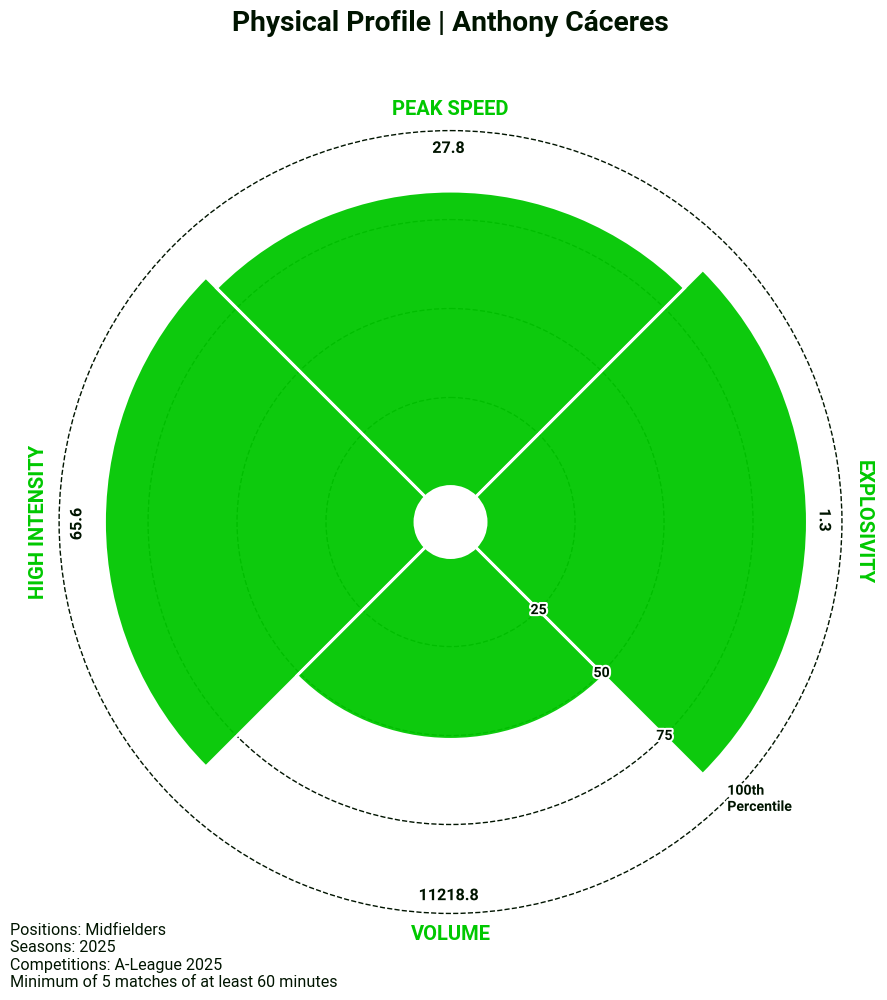

In [45]:
radar_df = physical_df[physical_df["position_group"] == "Midfield"].copy()

PHYSICAL = {
    "hi_count_p90": "High Intensity",
    "psv99": "Peak Speed",
    "timetosprint_top3": "Explosivity",
    "distance_p90": "Volume",
}

# Percentile Ranking (invert relevant ones)
lower_is_better = ["timetosprint_top3"]
higher_is_better = ["hi_count_p90", "psv99", "distance_p90"]

for metric in lower_is_better:
    # ascending=False ensures the LOWEST time gets the HIGHEST percentile
    radar_df[f"{metric}_pct"] = radar_df[metric].rank(pct=True, ascending=False) * 100

for metric in higher_is_better:
    # Standard percentile calculation (Higher value = Higher percentile)
    radar_df[f"{metric}_pct"] = radar_df[metric].rank(pct=True) * 100


# Plot off-ball run radar for x player
fig, ax = rad.plot_radar(
    radar_df,
    data_point_id="player_name",  # can also use player_id as data_point_id
    label="Anthony Cáceres",  # insert player
    plot_title="Physical Profile | Anthony Cáceres",
    metrics=PHYSICAL.keys(),
    metric_labels=PHYSICAL,
    suffix=" ",
    # Create your own sample text
    positions="Midfielders",
    matches=5,
    minutes=60,
    competitions="A-League 2025",
    seasons="2025",
    add_sample_info=True,
)


In [46]:
# Read and explore more about our physical data here: https://skillcorner.com/products/football/physical-data


In [47]:
physical_df.shape


(210, 68)